INICIANDO CODIGO OPTIMIZADO: PREDICCIONES 2026
📥 1. Cargando, limpiando y fusionando bases de datos...
Inteligencia temporal avanzada (Volatilidad y Tendencias)...
 Validando precisión del modelo optimizado ...
🎯 NUEVA PRECISIÓN VALIDADA: MAPE de 5.86%


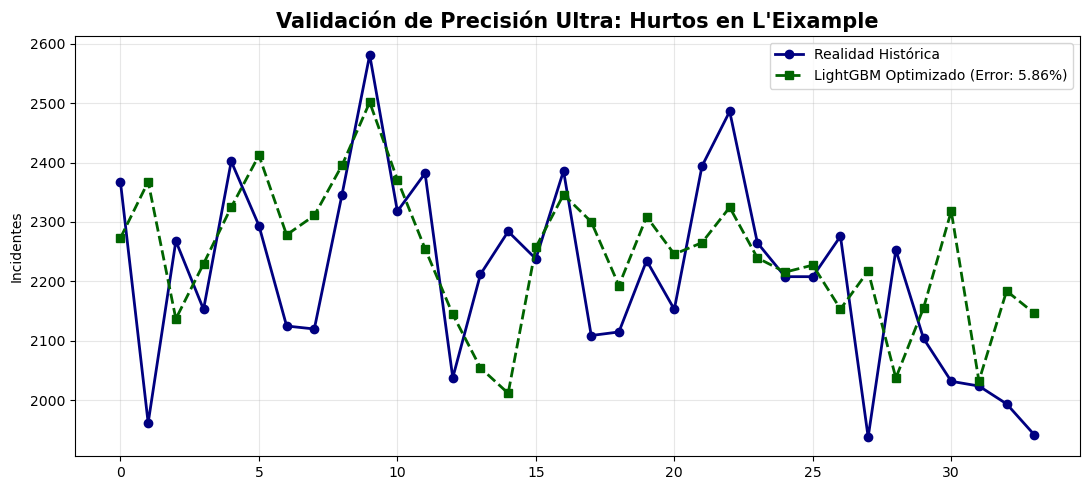

Proyectando 2026 con el nuevo motor predictivo...
✅ Nuevas predicciones exportadas a '03_Predicciones_Hurtos_2026.xlsx'
🎉 ¡PIPELINE  FINALIZADO!


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

print("INICIANDO CODIGO OPTIMIZADO: PREDICCIONES 2026")
print("=" * 70)

# ==========================================
# FASE 1: INGESTA Y LIMPIEZA DE DATOS
# ==========================================
print("📥 1. Cargando, limpiando y fusionando bases de datos...")

def limpiar_socio(path, pivot_col):
    df = pd.read_csv(path)
    if 'Poblacion' in path:
        df.columns = [str(col).split()[-1] if '01 ene' in str(col).lower() else col for col in df.columns]
    
    cols_num = [c for c in df.columns if c not in ['Territorio', 'Tipo de territorio', pivot_col]]
    for col in cols_num:
        df[col] = df[col].astype(str).str.replace(',', '.', regex=False).str.replace('-', '0', regex=False).replace('', '0').astype(float)
    
    melted = df.melt(id_vars=['Territorio', 'Tipo de territorio', pivot_col], var_name='Año', value_name='Val')
    melted['Año'] = pd.to_numeric(melted['Año'], errors='coerce')
    return melted.pivot_table(index=['Territorio', 'Año'], columns=pivot_col, values='Val', aggfunc='first').reset_index()

df_edad = limpiar_socio('Edad_Barrios.csv', 'Edad en grandes grupos')
df_pob = limpiar_socio('Poblacion-Inmigrante.csv', 'Nacionalidad (España/UE/Resto extranjero)')
df_crime = pd.read_csv('Criminalidad_Mensual_Estructurada.csv')

df_m = pd.merge(df_crime, df_edad, on=['Territorio', 'Año'], how='left')
df_m = pd.merge(df_m, df_pob, on=['Territorio', 'Año'], how='left')

df_m = df_m.rename(columns={'<16 años': 'Menos_16_anios', '≥65 años': 'Mas_65_anios', '16-64 años': 'Entre_16_64_anios'})
social_cols = ['Entre_16_64_anios', 'Menos_16_anios', 'Mas_65_anios', 'España', 'Resto del mundo']

df_m = df_m.sort_values(['Territorio', 'Categoría_Delito', 'Año', 'Mes_Num'])
df_m[social_cols] = df_m.groupby(['Territorio', 'Categoría_Delito'])[social_cols].ffill()
df_m = df_m.dropna(subset=social_cols).reset_index(drop=True)

# ==========================================
# FASE 2: FEATURE ENGINEERING AVANZADO
# ==========================================
print("Inteligencia temporal avanzada (Volatilidad y Tendencias)...")
def crear_variables_avanzadas(df):
    df = df.copy()
    
    # Lags Básicos y Estacionales
    df['Lag_1'] = df.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(1)
    df['Lag_2'] = df.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(2)
    df['Lag_3'] = df.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(3)
    df['Lag_11'] = df.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(11)
    df['Lag_12'] = df.groupby(['Territorio', 'Categoría_Delito'])['Cantidad'].shift(12)
    
    # Medias Móviles y Volatilidad
    df['Media_3_meses'] = df.groupby(['Territorio', 'Categoría_Delito'])['Lag_1'].transform(lambda x: x.rolling(window=3).mean())
    df['Media_6_meses'] = df.groupby(['Territorio', 'Categoría_Delito'])['Lag_1'].transform(lambda x: x.rolling(window=6).mean())
    df['Media_12_meses'] = df.groupby(['Territorio', 'Categoría_Delito'])['Lag_1'].transform(lambda x: x.rolling(window=12).mean())
    df['Std_3_meses'] = df.groupby(['Territorio', 'Categoría_Delito'])['Lag_1'].transform(lambda x: x.rolling(window=3).std())
    
    # Dinámica Interanual y Densidad Total
    df['Dif_Interanual'] = df['Lag_1'] - df['Lag_12']
    df['Poblacion_Total'] = df['España'] + df['Resto del mundo']
    
    return df.dropna().reset_index(drop=True)

df_model = crear_variables_avanzadas(df_m)

# ==========================================
# FASE 3: VALIDACIÓN CIENTÍFICA
# ==========================================
print(" Validando precisión del modelo optimizado ...")

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_11', 'Lag_12', 
            'Media_3_meses', 'Media_6_meses', 'Media_12_meses', 'Std_3_meses', 'Dif_Interanual',
            'Mes_Num', 'Poblacion_Total',
            'Entre_16_64_anios', 'Menos_16_anios', 'Mas_65_anios', 'España', 'Resto del mundo']

data_eval = df_model[(df_model['Territorio'] == 'Eixample') & (df_model['Categoría_Delito'] == 'Hurto')].copy()
X_eval = data_eval[features].values
y_eval = data_eval['Cantidad'].values

split = int(len(X_eval) * 0.8)
X_train, X_test = X_eval[:split], X_eval[split:]
y_train, y_test = y_eval[:split], y_eval[split:]

# Hiperparámetros ajustados para evitar sobreajuste y aprender mejor los matices
val_model = LGBMRegressor(
    num_leaves=20,          # Ligeramente más complejo que antes
    max_depth=5,            # Pero limitamos la profundidad para no memorizar ruido
    learning_rate=0.03,     # Aprende más despacio...
    n_estimators=350,       # ...pero le damos más iteraciones
    subsample=0.8,          # Usa el 80% de datos por árbol (robuztez)
    colsample_bytree=0.8,   # Usa el 80% de columnas por árbol
    random_state=42, 
    verbose=-1
)

val_model.fit(X_train, y_train)
y_pred_val = val_model.predict(X_test)
y_pred_val = [max(0, p) for p in y_pred_val]

mape_val = mean_absolute_percentage_error(y_test, y_pred_val) * 100
print(f"🎯 NUEVA PRECISIÓN VALIDADA: MAPE de {mape_val:.2f}%")

plt.figure(figsize=(11, 5))
plt.plot(y_test, label='Realidad Histórica', color='navy', marker='o', linewidth=2)
plt.plot(y_pred_val, label=f'LightGBM Optimizado (Error: {mape_val:.2f}%)', color='darkgreen', linestyle='--', marker='s', linewidth=2)
plt.title("Validación de Precisión Ultra: Hurtos en L'Eixample", fontsize=15, fontweight='bold')
plt.ylabel("Incidentes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('02_Validacion_Precision.png', dpi=300)
plt.show()

# ==========================================
# FASE 4: ENTRENAMIENTO TOTAL Y PREDICCIÓN 2026
# ==========================================
print("Proyectando 2026 con el nuevo motor predictivo...")
df_hurto = df_model[df_model['Categoría_Delito'] == 'Hurto'].copy()

X_full = df_hurto[features].values
y_full = df_hurto['Cantidad'].values

final_model = LGBMRegressor(
    num_leaves=20, max_depth=5, learning_rate=0.03, n_estimators=350, 
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
)
final_model.fit(X_full, y_full)

distritos = df_hurto['Territorio'].unique()
predicciones_2026 = []

for distrito in distritos:
    df_d = df_hurto[df_hurto['Territorio'] == distrito].tail(12).copy()
    demo_data = df_d.iloc[-1][['Entre_16_64_anios', 'Menos_16_anios', 'Mas_65_anios', 'España', 'Resto del mundo']].to_dict()
    historial = list(df_d['Cantidad'].values)
    
    for mes in range(1, 13):
        lag_1, lag_2, lag_3 = historial[-1], historial[-2], historial[-3]
        lag_11, lag_12 = historial[-11], historial[-12]
        
        media_3 = np.mean(historial[-3:])
        media_6 = np.mean(historial[-6:])
        media_12 = np.mean(historial[-12:])
        std_3 = np.std(historial[-3:], ddof=1)
        
        dif_interanual = lag_1 - lag_12
        pob_total = demo_data['España'] + demo_data['Resto del mundo']
        
        X_pred = np.array([[lag_1, lag_2, lag_3, lag_11, lag_12, 
                            media_3, media_6, media_12, std_3, dif_interanual, 
                            mes, pob_total,
                            demo_data['Entre_16_64_anios'], demo_data['Menos_16_anios'], 
                            demo_data['Mas_65_anios'], demo_data['España'], demo_data['Resto del mundo']]])
        
        pred_val = final_model.predict(X_pred)[0]
        pred_val = max(0, int(round(pred_val)))
        
        predicciones_2026.append({
            'Territorio': distrito, 'Categoría_Delito': 'Hurto', 
            'Año': 2026, 'Mes_Num': mes, 'Predicción_Incidentes': pred_val
        })
        historial.append(pred_val)

df_2026 = pd.DataFrame(predicciones_2026)
df_2026.to_excel('AA_Predicciones_Hurtos_2026.xlsx', index=False)
print("✅ Nuevas predicciones exportadas a '03_Predicciones_Hurtos_2026.xlsx'")

print("=" * 70)
print("🎉 ¡PIPELINE  FINALIZADO!")

📊 GENERANDO INTELIGENCIA VISUAL Y GRÁFICAS ESTRATÉGICAS...


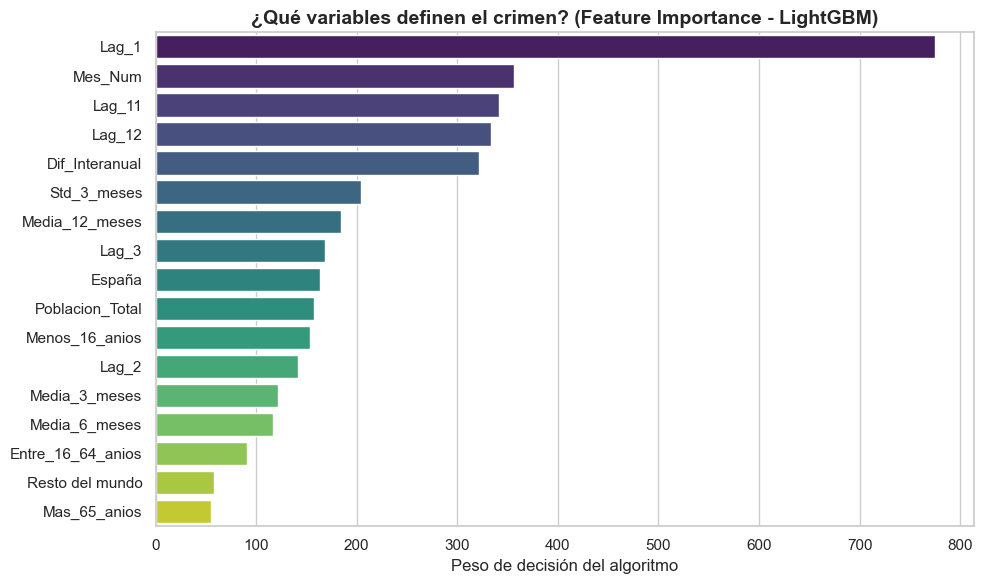

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

print("📊 GENERANDO INTELIGENCIA VISUAL Y GRÁFICAS ESTRATÉGICAS...")
sns.set_theme(style="whitegrid")

# ==========================================
# GRÁFICA 1: IMPORTANCIA DE LAS VARIABLES (Feature Importance)
# ==========================================
# ¿Qué mira el modelo para decidir?
importancias = final_model.feature_importances_
df_importancia = pd.DataFrame({'Variable': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('¿Qué variables definen el crimen? (Feature Importance - LightGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Peso de decisión del algoritmo')
plt.ylabel('')
plt.tight_layout()
plt.savefig('04_Importancia_Variables.png', dpi=300)
plt.show()






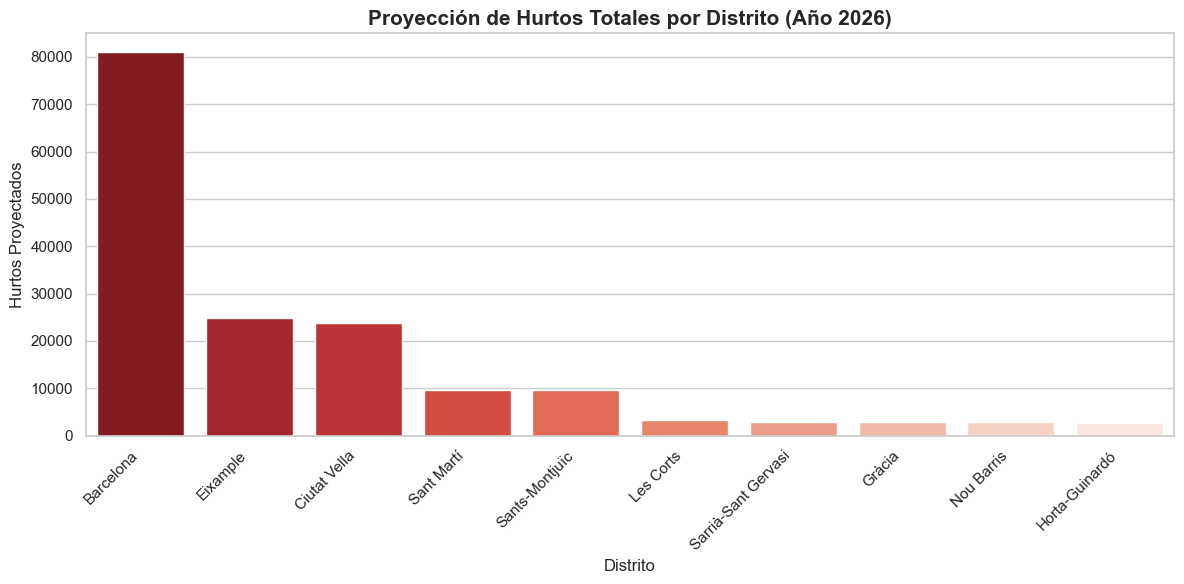

In [3]:
# ==========================================
# GRÁFICA 2: RANKING DE HOTSPOTS 2026 (Total Acumulado)
# ==========================================
# ¿Qué distritos sufrirán más hurtos en todo el año?
ranking_2026 = df_2026.groupby('Territorio')['Predicción_Incidentes'].sum().reset_index()
ranking_2026 = ranking_2026.sort_values('Predicción_Incidentes', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Territorio', y='Predicción_Incidentes', data=ranking_2026, palette='Reds_r')
plt.title('Proyección de Hurtos Totales por Distrito (Año 2026)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Hurtos Proyectados')
plt.xlabel('Distrito')
plt.tight_layout()
plt.savefig('05_Ranking_Distritos_2026.png', dpi=300)
plt.show()

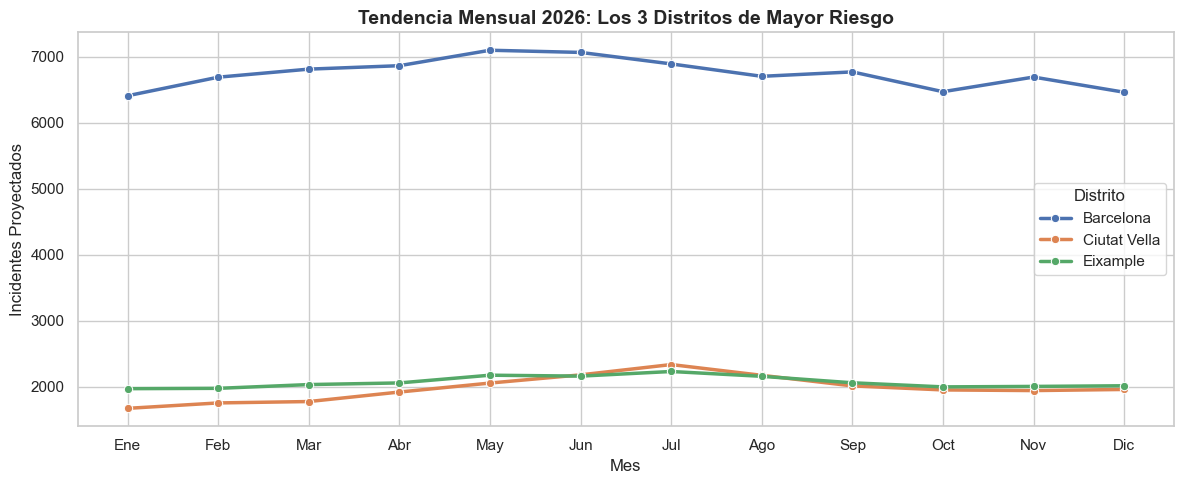

In [4]:
# ==========================================
# GRÁFICA 3: EVOLUCIÓN MENSUAL DE LOS TOP 3 DISTRITOS
# ==========================================
# ¿Cuándo son los picos de criminalidad en las zonas más calientes?
top_3_distritos = ranking_2026.head(3)['Territorio'].tolist()
df_top3 = df_2026[df_2026['Territorio'].isin(top_3_distritos)]

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_top3, x='Mes_Num', y='Predicción_Incidentes', hue='Territorio', marker='o', linewidth=2.5)
plt.title('Tendencia Mensual 2026: Los 3 Distritos de Mayor Riesgo', fontsize=14, fontweight='bold')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.ylabel('Incidentes Proyectados')
plt.xlabel('Mes')
plt.legend(title='Distrito')
plt.tight_layout()
plt.savefig('06_Evolucion_Top3_2026.png', dpi=300)
plt.show()


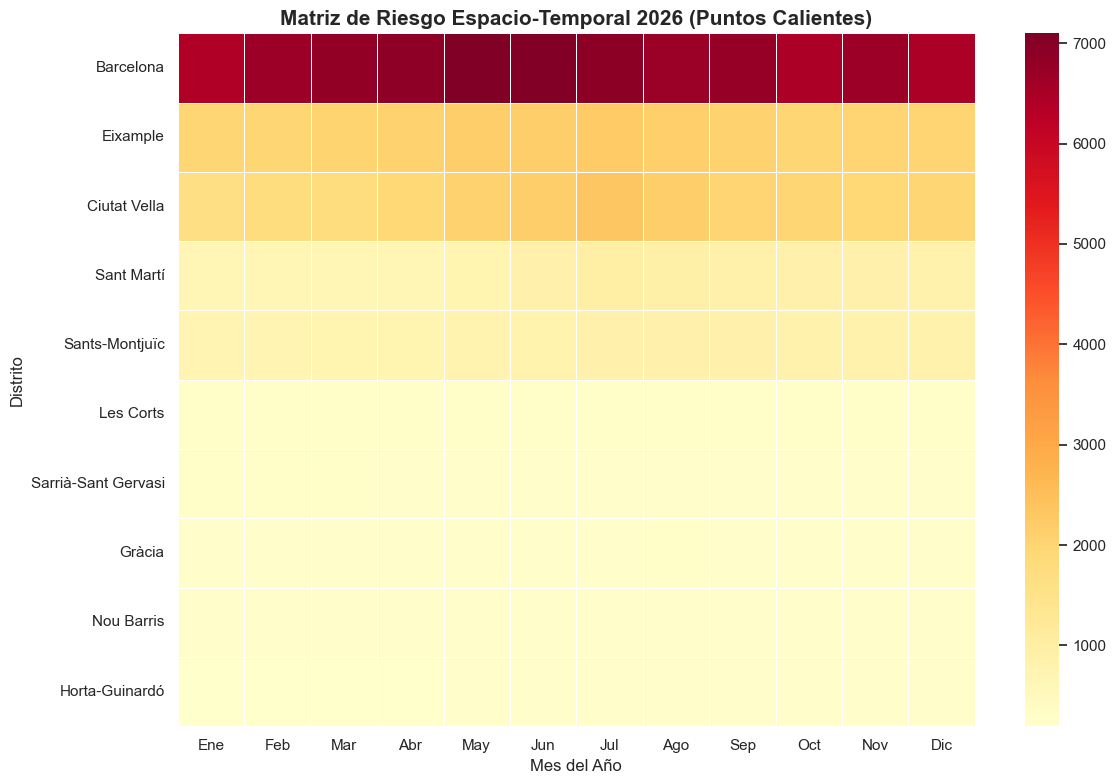

✅ Gráficas generadas y guardadas como imágenes PNG.


In [5]:
# ==========================================
# GRÁFICA 4: MAPA DE CALOR ESPACIO-TEMPORAL (Heatmap)
# ==========================================
# La herramienta definitiva para asignar patrullas policiales
heatmap_data = df_2026.pivot_table(index='Territorio', columns='Mes_Num', values='Predicción_Incidentes', aggfunc='sum')
# Ordenamos el heatmap para que los distritos peores salgan arriba
heatmap_data = heatmap_data.loc[ranking_2026['Territorio']] 

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=.5)
plt.title('Matriz de Riesgo Espacio-Temporal 2026 (Puntos Calientes)', fontsize=15, fontweight='bold')
plt.xlabel('Mes del Año')
plt.ylabel('Distrito')
plt.xticks(ticks=np.arange(0.5, 12.5), labels=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.tight_layout()
plt.savefig('07_Heatmap_Riesgo_2026.png', dpi=300)
plt.show()

print("✅ Gráficas generadas y guardadas como imágenes PNG.")

In [13]:
import folium
from folium.plugins import HeatMap
import pandas as pd

print("🌍 GENERANDO MAPA TÁCTICO INTERACTIVO (CON INFORMES POR DISTRITO)...")

# 1. Total de predicciones para 2026
df_mapa = df_2026.groupby('Territorio')['Predicción_Incidentes'].sum().reset_index()

# 2. Rescatamos la "foto demográfica" más reciente de tu modelo original
df_demo = df_model[df_model['Categoría_Delito'] == 'Hurto'].drop_duplicates(subset=['Territorio'], keep='last')
cols_demo = ['Territorio', 'Poblacion_Total', 'Entre_16_64_anios', 'España', 'Resto del mundo']
df_demo = df_demo[cols_demo]

# 3. Fusionamos los delitos predichos con la demografía
df_final_mapa = pd.merge(df_mapa, df_demo, on='Territorio')

coordenadas_bcn = {
    'Ciutat Vella': [41.3828, 2.1769], 'Eixample': [41.3889, 2.1589],
    'Sants-Montjuïc': [41.3634, 2.1433], 'Les Corts': [41.3840, 2.1310],
    'Sarrià-Sant Gervasi': [41.4010, 2.1280], 'Gràcia': [41.4080, 2.1560],
    'Horta-Guinardó': [41.4300, 2.1620], 'Nou Barris': [41.4415, 2.1764],
    'Sant Andreu': [41.4355, 2.1895], 'Sant Martí': [41.4060, 2.2000]
}

mapa_bcn = folium.Map(location=[41.3900, 2.1600], zoom_start=12, tiles='cartodbpositron')
datos_calor = []

for index, row in df_final_mapa.iterrows():
    distrito = row['Territorio']
    hurtos = row['Predicción_Incidentes']
    pob_total = row['Poblacion_Total']
    
    # EL PARCHE MATEMÁTICO: Convertimos el formato "6324" a su porcentaje (63.24%) 
    # y lo multiplicamos por la población total del distrito.
    porcentaje_activos = row['Entre_16_64_anios'] / 100
    activos_reales = porcentaje_activos * pob_total
    
    extranjeros = row['Resto del mundo']
    
    if distrito in coordenadas_bcn:
        lat, lon = coordenadas_bcn[distrito]
        datos_calor.append([lat, lon, hurtos])
        
        # HTML Actualizado con la variable 'activos_reales'
        html_popup = f"""
        <div style="font-family: Arial, sans-serif; min-width: 220px;">
            <h4 style="margin-bottom: 5px; color: #8B0000;"><b>📍 {distrito}</b></h4>
            <hr style="margin: 5px 0; border: 1px solid #ccc;">
            <p style="margin: 5px 0; font-size: 14px;">
                <b>🚨 Alerta Hurtos 2026:</b> <span style="color: red; font-size: 16px;"><b>{int(hurtos)}</b></span><br><br>
                <b>👥 Contexto Demográfico:</b><br>
                • Población Total: {int(pob_total):,} hab.<br>
                • Pob. Activa (16-64): {int(activos_reales):,} hab.<br>
                • Población Extranjera: {int(extranjeros):,} hab.
            </p>
        </div>
        """
        
        iframe = folium.IFrame(html=html_popup, width=250, height=180)
        popup_interactivo = folium.Popup(iframe, max_width=250)
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=25, 
            color='transparent',
            fill=True,
            fill_color='transparent',
            tooltip=f"👆 Haz clic para ver el informe de {distrito}",
            popup=popup_interactivo
        ).add_to(mapa_bcn)

HeatMap(
    datos_calor, 
    radius=45, blur=30, max_zoom=1, 
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1.0: 'red'}
).add_to(mapa_bcn)

archivo_mapa = '08_Mapa_Calor_Tactico_2026.html'
mapa_bcn.save(archivo_mapa)

print("✅ ¡Mapa táctico generado! Haz clic en las zonas rojas para ver el desglose:")

# Muestra el mapa directamente en Jupyter
mapa_bcn

🌍 GENERANDO MAPA TÁCTICO INTERACTIVO (CON INFORMES POR DISTRITO)...
✅ ¡Mapa táctico generado! Haz clic en las zonas rojas para ver el desglose:


In [12]:
# 🔎 RADIOGRAFÍA DE LOS DATOS DE EDAD
print("Mostrando cómo ha leído Python el archivo de edades para Sarrià:")
df_diagnostico = df_edad[df_edad['Territorio'].str.contains("Sarrià", case=False, na=False)]

# Mostramos los últimos 3 años para ver los números crudos
display(df_diagnostico.tail(3))

Mostrando cómo ha leído Python el archivo de edades para Sarrià:


Edad en grandes grupos,Territorio,Año,16-64 años,<16 años,≥65 años
316,Sarrià-Sant Gervasi,2023,62.50,15.68,21.82
317,Sarrià-Sant Gervasi,2024,62.97,15.31,21.72
318,Sarrià-Sant Gervasi,2025,63.24,15.06,21.69
